In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib


df = pd.read_csv('cardio_train_cleaned.csv')


print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

def bulletproof_prepare_features(df):
    data = df.copy()
    
    if 'weight' in data.columns and 'height' in data.columns:
        data['bmi'] = data['weight'] / ((data['height']/100)**2)
    else:
        data['bmi'] = 25.0  
    
    if 'ap_hi' in data.columns and 'ap_lo' in data.columns:
        data['pulse_pressure'] = data['ap_hi'] - data['ap_lo']
    else:
        data['pulse_pressure'] = 40  # Default pulse pressure
    
    required_features = [
        'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 
        'gluc', 'smoke', 'alco', 'active', 'age', 'bmi', 'pulse_pressure'
    ]
    
    X_data = {}
    
    for feature in required_features:
        if feature == 'bmi':
            X_data['bmi'] = data.get('bmi', 25.0)
        elif feature == 'pulse_pressure':
            X_data['pulse_pressure'] = data.get('pulse_pressure', 40)
        elif feature == 'age':
            # Safe age handling
            age_col = None
            for col in data.columns:
                if 'age' in col.lower():
                    age_col = col
                    break
            if age_col:
                X_data['age'] = data[age_col]
            else:
                print(" No age column → using default age 55")
                X_data['age'] = 55
        else:
            if feature in data.columns:
                X_data[feature] = data[feature]
            else:
                print(f"Missing {feature} → using default 0")
                X_data[feature] = 0
    
    X = pd.DataFrame(X_data)[required_features]
    y = data['cardio']
    
    return X, y

X, y = bulletproof_prepare_features(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

cm = confusion_matrix(y_test, y_pred)


print(f"Accuracy:  {metrics['accuracy']*100:.1f}%")
print(f"Precision: {metrics['precision']*100:.1f}%")
print(f"Recall:    {metrics['recall']*100:.1f}%")
print(f"Confusion: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")


joblib.dump(pipeline, "cardio_logistic_model.pkl")
joblib.dump(list(X.columns), "model_features.pkl")
joblib.dump(metrics, "model_metrics.pkl")
joblib.dump(cm, "confusion_matrix.pkl")

# K-Fold cross validation
print("K-Fold Accuracy:",
      cross_val_score(pipeline, X, y, cv=5).mean())

params = {
    "lr__C": [0.01, 0.1, 1, 5, 10],
    "lr__solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(pipeline, params, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

print("Tuned Accuracy:",
      accuracy_score(y_test, grid.predict(X_test)))


Shape: (68742, 14)
Columns: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI', 'pulse_pressure']
Accuracy:  72.1%
Precision: 74.1%
Recall:    66.9%
Confusion: TN=5359, FP=1587, FN=2251, TP=4552
K-Fold Accuracy: 0.7199819806505143
Best Parameters: {'lr__C': 5, 'lr__solver': 'lbfgs'}
Tuned Accuracy: 0.7212160884427958


 MODEL PERFORMANCE VISUALIZATION ===


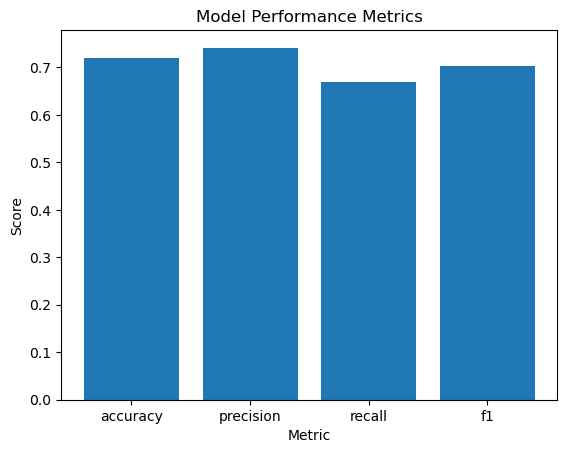

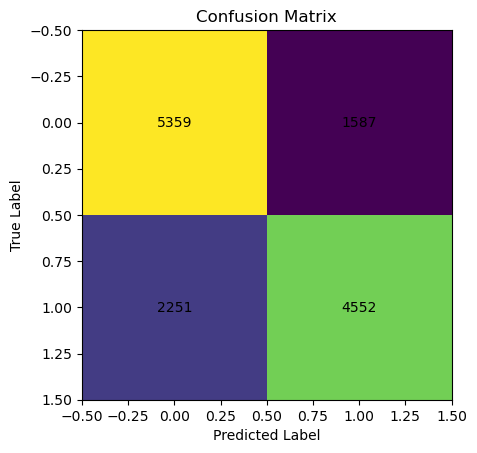

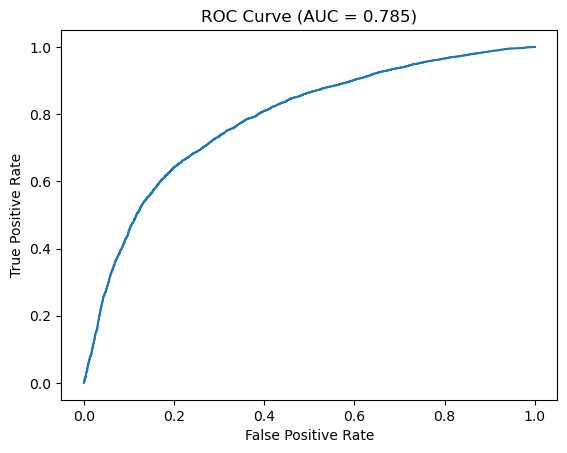

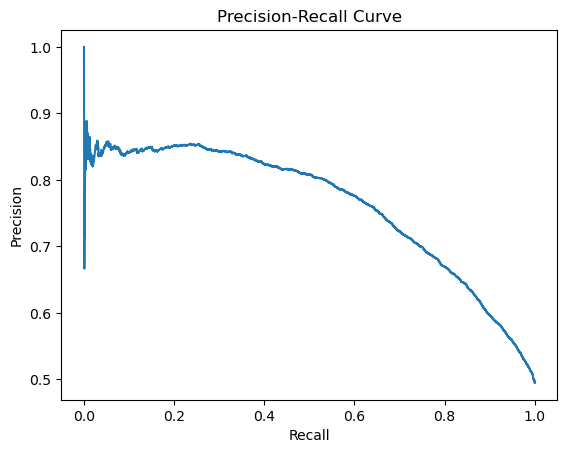

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

print(" MODEL PERFORMANCE VISUALIZATION ===")

# ---------- 1. METRIC BAR CHART ----------
plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.title("Model Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()

# ---------- 2. CONFUSION MATRIX HEATMAP ----------
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# ---------- 3. ROC CURVE ----------
y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# ---------- 4. PRECISION-RECALL CURVE ----------
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


